# Matplotlib Visualization: BigBasket Products

**Objective:** Learn the core Matplotlib plot types (line, bar, histogram, box, scatter) and how to customize them, using a real-world product dataset.

**Dataset:** `../data/BigBasket_Products.csv` (27,555 products x 10 columns)

---

### In this notebook:
- **Section 1:** Getting Started  
- **Section 2:** Types of Plots  
- **Section 3:** Plot Customization  

---

##  Section 1: Getting Started with Matplotlib

### 1. What is Matplotlib?
Matplotlib is a comprehensive library for creating **static, animated, and interactive visualizations** in Python.  
It is one of the most popular plotting libraries used by **data scientists and analysts**.

**Why use Matplotlib?**
-  Visualize patterns and trends in data  
-  Easy to understand complex datasets  
-  Create publication-quality figures  
-  Highly customizable plots  
-  Supports multiple plot types  

---

### 2. Installing Matplotlib
```bash
pip install matplotlib
```

In [1]:
# pip install matplotlib - run this command by removing #

In [2]:
# import library:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Load the dataset
from pathlib import Path

# Look for data/BigBasket_Products.csv (also accepts "BigBasket Products.csv")
# starting from this notebook's folder and moving upward through parent folders.
here = Path.cwd().resolve()
csv_path = None
for folder in [here, *here.parents]:
    found = sorted(folder.glob("data/BigBasket*Products*.csv"))
    if found:
        csv_path = found[0]
        break

if csv_path is None:
    raise FileNotFoundError(
        "Could not find data/BigBasket_Products.csv. "
        "Open this notebook from the 'notebooks' folder of the project."
    )

df = pd.read_csv(csv_path)
print("Loaded:", csv_path.name, df.shape)

Loaded: BigBasket_Products.csv (27555, 10)


In [4]:
# Quick peek at the dataset
df.head(2)

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
0,1,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.0,220.0,Hair Oil & Serum,4.1,This Product contains Garlic Oil that is known...
1,2,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.0,180.0,Water & Fridge Bottles,2.3,"Each product is microwave safe (without lid), ..."


## Quick Data Exploration

Before diving into visualizations, it’s important to **understand the dataset**.  
Here are some quick checks you can run:

```python
# Dataset shape (rows, columns)
print("Dataset Shape:", df.shape)

# Display first 5 rows
print("\nFirst 5 rows:")
print(df.head())

# Data types of each column
print("\nData Types:")
print(df.dtypes)

# Count of missing values in each column
print("\nMissing Values:")
print(df.isnull().sum())


In [5]:
# Dataset shape (rows, columns)
print("Dataset Shape:", df.shape)

Dataset Shape: (27555, 10)


In [6]:
# Display first 5 rows
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
   index                                            product  \
0      1             Garlic Oil - Vegetarian Capsule 500 mg   
1      2                              Water Bottle - Orange   
2      3                     Brass Angle Deep - Plain, No.2   
3      4  Cereal Flip Lid Container/Storage Jar - Assort...   
4      5                 Creme Soft Soap - For Hands & Body   

                 category           sub_category              brand  \
0        Beauty & Hygiene              Hair Care  Sri Sri Ayurveda    
1  Kitchen, Garden & Pets  Storage & Accessories         Mastercook   
2    Cleaning & Household            Pooja Needs                Trm   
3    Cleaning & Household   Bins & Bathroom Ware             Nakoda   
4        Beauty & Hygiene       Bath & Hand Wash              Nivea   

   sale_price  market_price                      type  rating  \
0       220.0         220.0          Hair Oil & Serum     4.1   
1       180.0         180.0    Water & Fridge Bot

In [7]:
# Data types of each column
print("\nData Types:")
print(df.dtypes)


Data Types:
index             int64
product             str
category            str
sub_category        str
brand               str
sale_price      float64
market_price    float64
type                str
rating          float64
description         str
dtype: object


In [8]:
# Count of missing values in each column
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
index              0
product            1
category           0
sub_category       0
brand              1
sale_price         0
market_price       0
type               0
rating          8626
description      115
dtype: int64


##  4. Basic Syntax for Creating a Plot

The **standard structure** for creating a simple plot in Matplotlib is:

```python
plt.plot(x_data, y_data)    # Create the plot
plt.show()                  # Display the plot


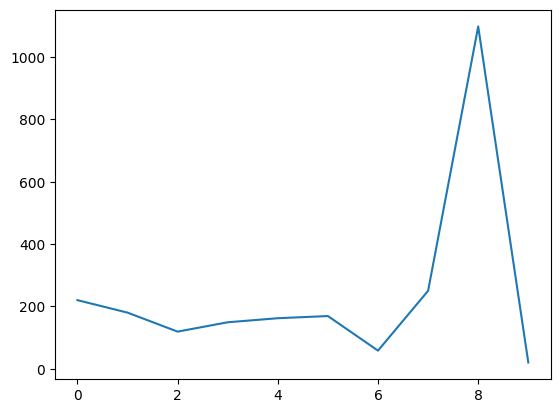

In [9]:
# Simple Example — Plotting First 10 Sale Prices

plt.plot(df['sale_price'].head(10))
plt.show()

#### How to Read the Plot

- **X-axis (horizontal)** → Product position in the dataset (not product ID, just row index).  
- **Y-axis (vertical)** → Sale price of that product.  

###  Line Trend Interpretation
-  **Sharp spike at index 8** → Product 9 (*Biotin & Collagen Shampoo*) has a very high price (**1098.0**).  
-  **Drop at index 9** → Product 10 (*Scrub Pad*) is very cheap (**20.0**).  
-  **Smaller ups and downs in between** → Reflect moderate price differences among other products.  


# Section 2: Types of Plots

## 5. Line Plot

###  Purpose
Line plots are used to **show trends over continuous data or sequences**.  
They are best suited for:
- Time series data  
- Sequential data  
- Continuous relationships  

---


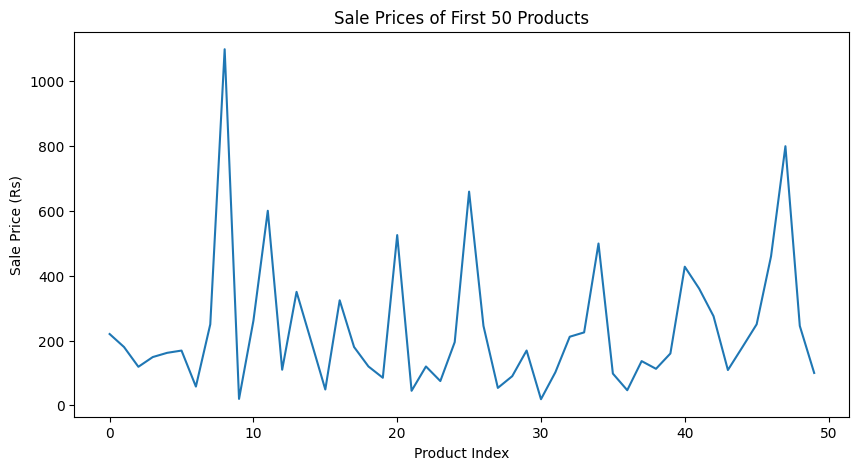

In [10]:
###  Example 1: Sale Prices of First 50 Products

plt.figure(figsize=(10, 5))
plt.plot(df['sale_price'].head(50))
plt.title('Sale Prices of First 50 Products')
plt.xlabel('Product Index')
plt.ylabel('Sale Price (Rs)')
plt.show()

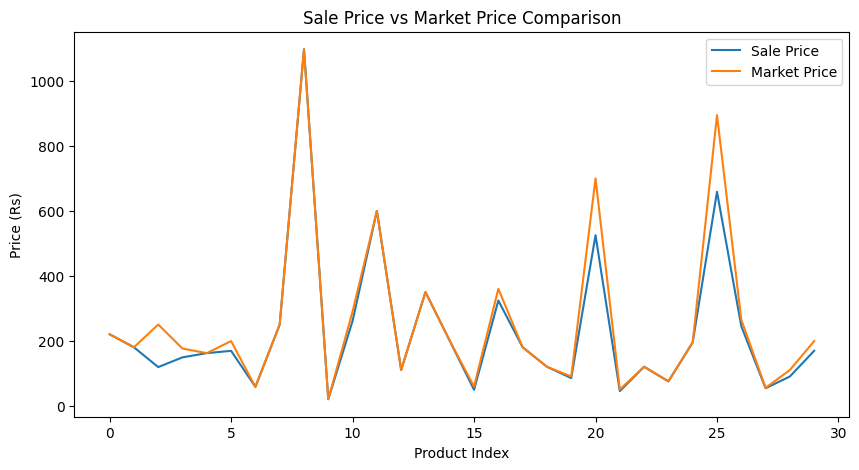

In [11]:
## Example 2: Comparing Sale Price vs Market Price

plt.figure(figsize=(10, 5))
sample_data = df.head(30)
plt.plot(sample_data.index, sample_data['sale_price'], label='Sale Price')
plt.plot(sample_data.index, sample_data['market_price'], label='Market Price')
plt.title('Sale Price vs Market Price Comparison')
plt.xlabel('Product Index')
plt.ylabel('Price (Rs)')
plt.legend()
plt.show()


# Section 2: Types of Plots

## 6. Bar Plot

###  Purpose
Bar plots are used to **compare values across different categories**.  
They are best suited for:
- Categorical comparisons  
- Rankings  

---

### Example Data
- Suppose we have the sales of 4 products:


| Product   | Sales |
|-----------|-------|
| Soap      | 50    |
| Shampoo   | 80    |
| Toothpaste| 40    |
| Lotion    | 70    |



In [12]:
products = ['Soap', 'Shampoo', 'Toothpaste', 'Lotion']
sales = [50, 80, 40, 70]

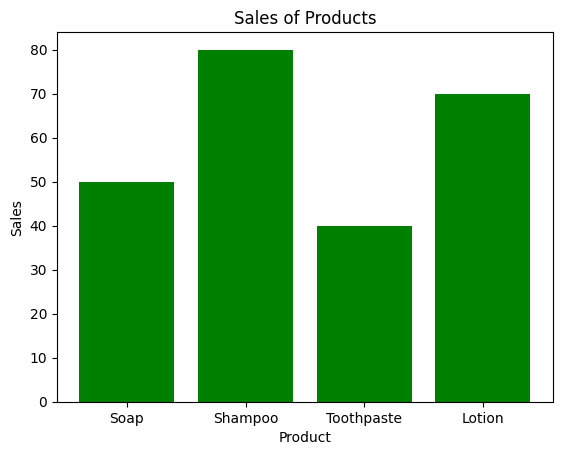

In [13]:
# Create bar plot
plt.bar(products, sales, color='Green')
plt.title('Sales of Products')
plt.xlabel('Product')
plt.ylabel('Sales')
plt.show()

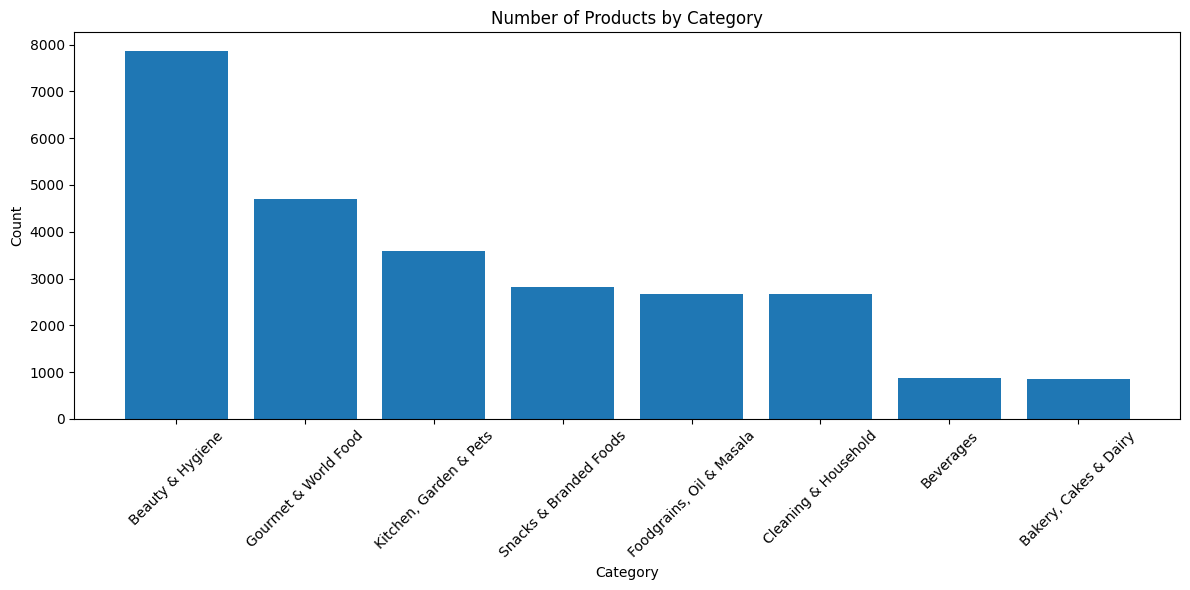

In [14]:
### Example 1: Count of Products by Category

category_counts = df['category'].value_counts().head(8)

plt.figure(figsize=(12, 6))
plt.bar(category_counts.index, category_counts.values)
plt.title('Number of Products by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

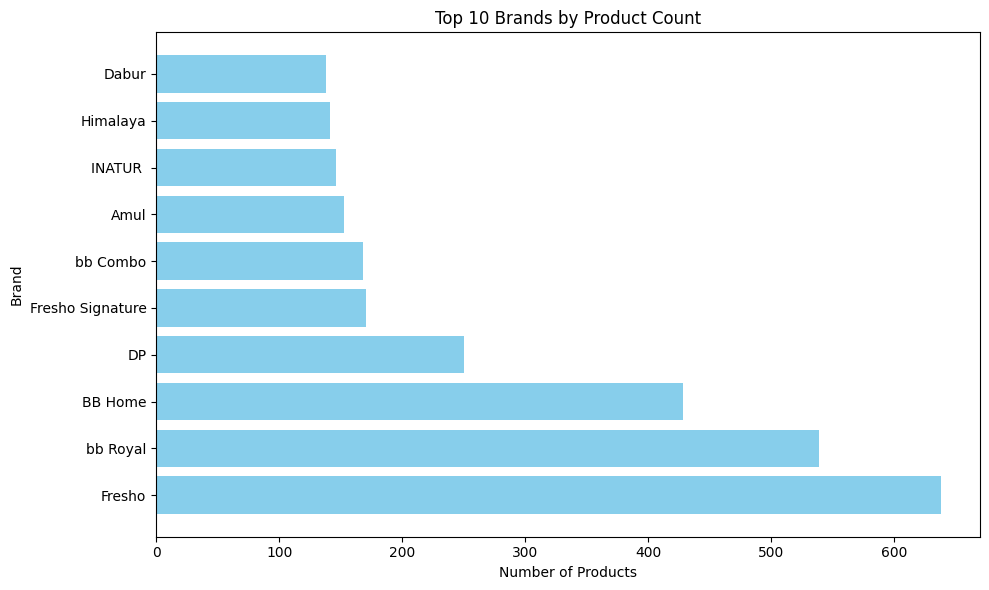

In [15]:
## Example 2: Horizontal Bar Plot – Top 10 Brands


brand_counts = df['brand'].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(brand_counts.index, brand_counts.values, color='skyblue')
plt.title('Top 10 Brands by Product Count')
plt.xlabel('Number of Products')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

## 7. HISTOGRAM

### Purpose
Histograms are used to **show the distribution and frequency of data**.  
They are best suited for:
- Understanding how data is spread  
- Detecting patterns in numerical data  
- Identifying skewness, peaks, and 

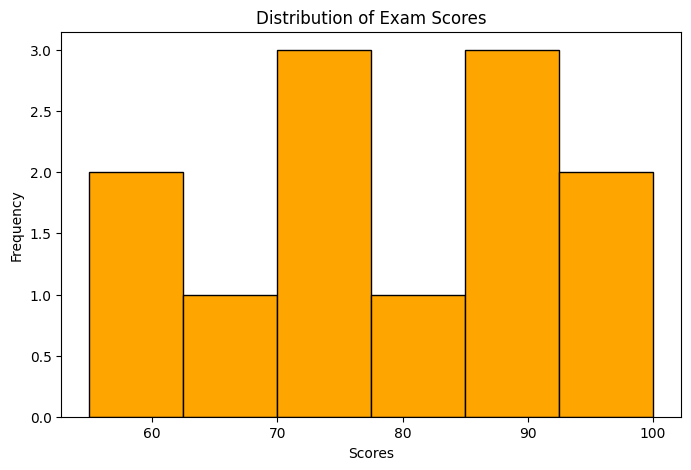

In [16]:
# Sample data: exam scores of 12 students
scores = [55, 60, 65, 70, 70, 75, 80, 85, 85, 90, 95, 100]

# Create histogram
plt.figure(figsize=(8, 5))
plt.hist(scores, bins=6, color='orange', edgecolor='black')
plt.title('Distribution of Exam Scores')
plt.xlabel('Scores')
plt.ylabel('Frequency')
plt.show()

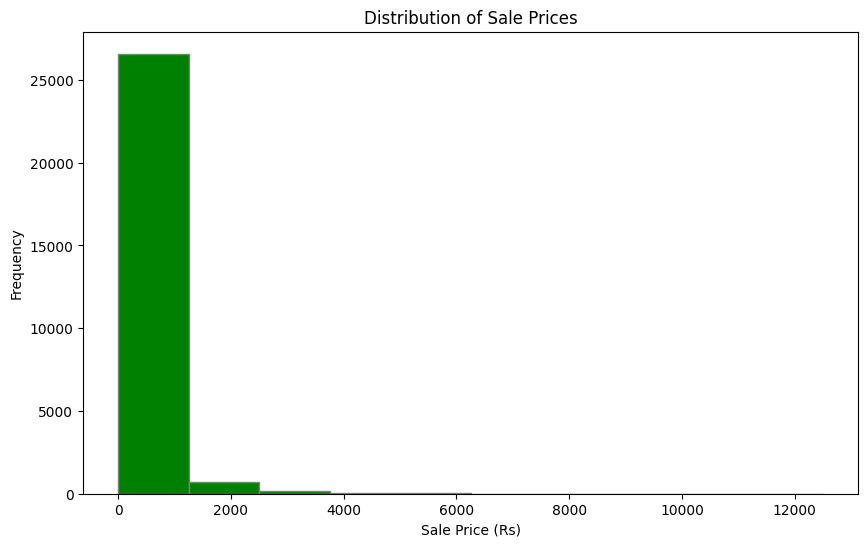

In [17]:
# Example 1: Distribution of Sale Prices

plt.figure(figsize=(10, 6))
plt.hist(df['sale_price'], bins=10, color='green', edgecolor='grey')
plt.title('Distribution of Sale Prices')
plt.xlabel('Sale Price (Rs)')
plt.ylabel('Frequency')
plt.show()

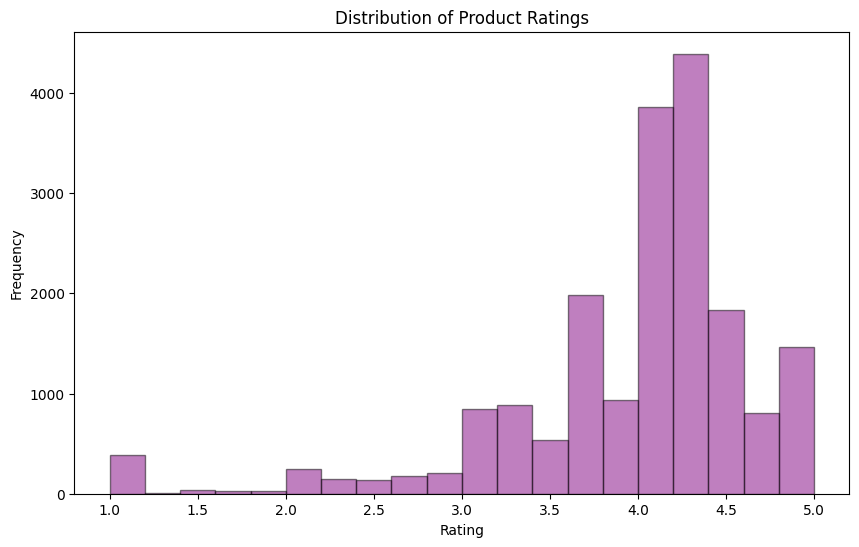

In [18]:
# Example 2: Distribution of ratings (removing NaN values)

ratings_clean = df['rating'].dropna()

plt.figure(figsize=(10, 6))
plt.hist(ratings_clean, bins=20, color='purple', edgecolor='black', alpha=0.5)
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()


## 8. BOX PLOT

---

###  Purpose
Box plots are used to **show data distribution, median, quartiles, and outliers**.  
They are best suited for:
- Detecting outliers  
- Comparing distributions across categories  

---

###  Box Plot Components

- **Box** → Represents the **interquartile range (IQR)**, which is the middle 50% of the data.  
- **Line inside the box** → The **median value** (middle of the dataset).  
- **Whiskers** → Extend from the box to show the overall **range of data** (excluding outliers).  
- **Dots (or circles)** → Represent **outliers**, i.e., values that are unusually high or low compared to the rest of the data.  

---

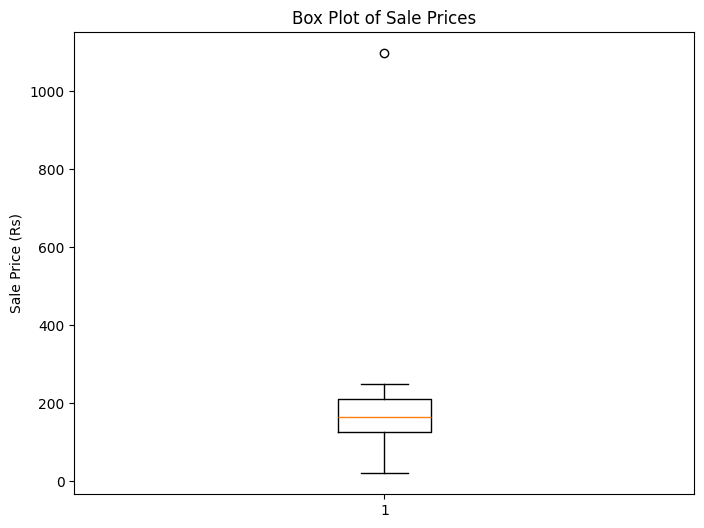

In [19]:
# Sample data: product sale prices
sale_prices = [220, 180, 119, 149, 162, 169, 58, 250, 1098, 20]

plt.figure(figsize=(8, 6))
plt.boxplot(sale_prices)
plt.title('Box Plot of Sale Prices')
plt.ylabel('Sale Price (Rs)')
plt.show()

- **Box** → Shows where most product prices lie (the middle 50% of data, called the IQR).  
- **Line inside the box** → Represents the median price (the middle value of the dataset).  
- **Whiskers** → Extend to cover the lowest and highest typical prices (excluding outliers).  
- **Dot at 1098** → Appears as an outlier, since it’s much higher than the rest of the product prices.  

##  Understanding the Box Plot Lines

In a **box plot**, the box itself represents the **interquartile range (IQR)** — the middle 50% of the data.  
Here’s what each line means:

- **Bottom line of the box (Q1)**  
  → This is the **first quartile (25th percentile)**.  
  → It marks the value below which 25% of the data falls.  
  → In other words, one-fourth of the data lies below this line.

- **Middle line inside the box (Median)**  
  → This is the **median (50th percentile)**.  
  → It represents the middle value of the dataset when sorted.  
  → Half of the data lies below this line, and half lies above.

- **Top line of the box (Q3)**  
  → This is the **third quartile (75th percentile)**.  
  → It marks the value below which 75% of the data falls.  
  → In other words, three-fourths of the data lies below this line.

---

### Summary
- **Bottom line (Q1)** → 25% of data below.  
- **Middle line (Median)** → 50% of data below.  
- **Top line (Q3)** → 75% of data below.  

Together, these three lines show the **spread of the central portion of the data**.



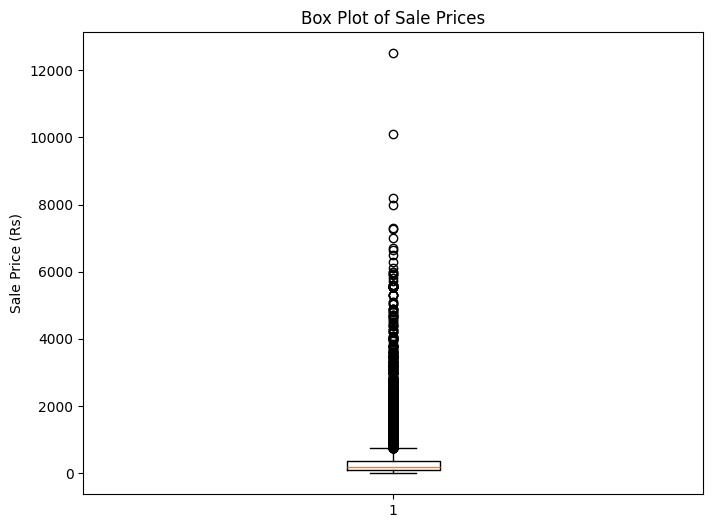

In [20]:
# Example 1: Box plot of sale prices
plt.figure(figsize=(8, 6))
plt.boxplot(df['sale_price'].dropna())
plt.title('Box Plot of Sale Prices')
plt.ylabel('Sale Price (Rs)')
plt.show()

# 9. SCATTER PLOT

---

###  Purpose
Scatter plots are used to **show the relationship between two numerical variables**.  
They are best suited for:
- Finding correlations (positive, negative, or none)  
- Identifying patterns, clusters, or trends in data  
- Spotting unusual points (outliers)  

---

In [21]:
# Sample data: hours studied vs exam scores
study_hours = [1, 2, 3, 4, 5, 6, 7, 8]
exam_scores = [50, 55, 60, 65, 70, 75, 80, 90]

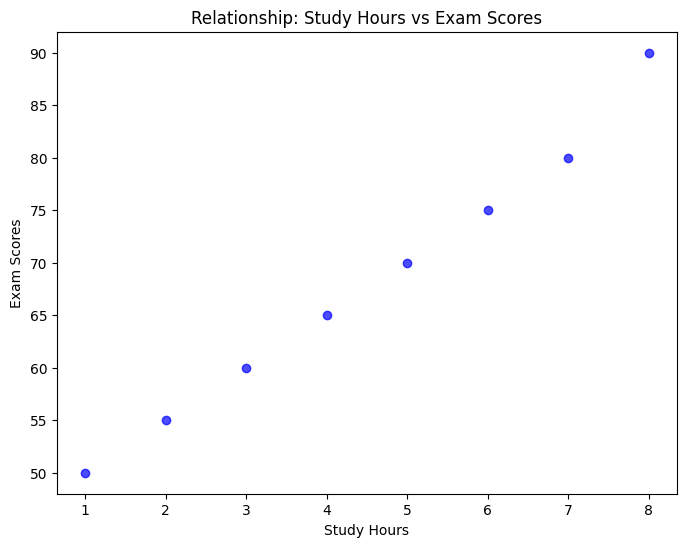

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(study_hours, exam_scores, color='blue', alpha=0.7)
plt.title('Relationship: Study Hours vs Exam Scores')
plt.xlabel('Study Hours')
plt.ylabel('Exam Scores')
plt.show()

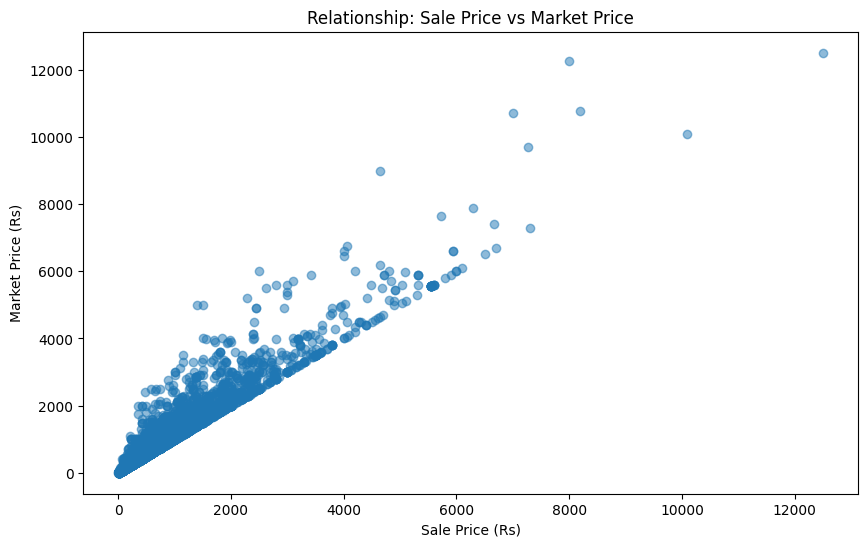

In [23]:
###  Example 1: Relationship between Sale Price and Market Price


plt.figure(figsize=(10, 6))
plt.scatter(df['sale_price'], df['market_price'], alpha=0.5)
plt.title('Relationship: Sale Price vs Market Price')
plt.xlabel('Sale Price (Rs)')
plt.ylabel('Market Price (Rs)')
plt.show()

# 10. Adding Titles, Axis Labels, and Legends

---

###  Purpose
Titles, axis labels, and legends make plots **informative and professional**.  
They help viewers quickly understand what the chart represents and improve readability.

---

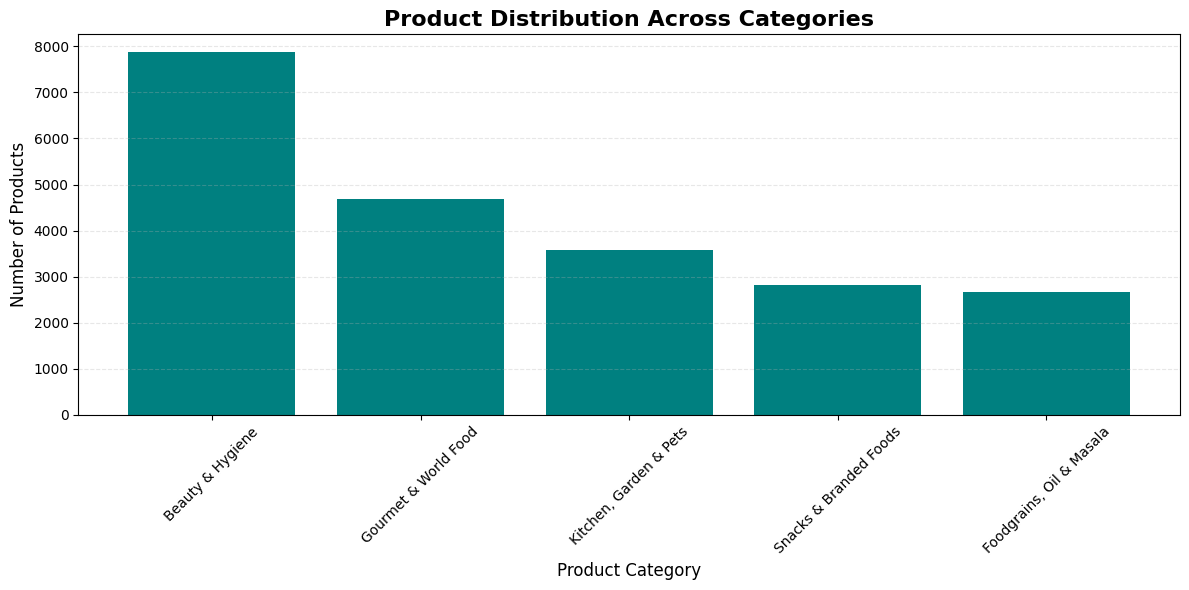

In [24]:
plt.figure(figsize=(12, 6))

# Create plot
category_counts = df['category'].value_counts().head(5)
plt.bar(category_counts.index, category_counts.values, color='teal')

# Add title (larger font, bold)
plt.title('Product Distribution Across Categories', fontsize=16, fontweight='bold')

# Add axis labels with font size
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Add grid for better readability
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Tight layout to prevent label cutoff
plt.tight_layout()
plt.show()


In [25]:
category_counts = df['category'].value_counts()
category_counts

category
Beauty & Hygiene            7867
Gourmet & World Food        4690
Kitchen, Garden & Pets      3580
Snacks & Branded Foods      2814
Foodgrains, Oil & Masala    2676
Cleaning & Household        2675
Beverages                    885
Bakery, Cakes & Dairy        851
Baby Care                    610
Fruits & Vegetables          557
Eggs, Meat & Fish            350
Name: count, dtype: int64

In [26]:
category_counts.index[0:5]

Index(['Beauty & Hygiene', 'Gourmet & World Food', 'Kitchen, Garden & Pets',
       'Snacks & Branded Foods', 'Foodgrains, Oil & Masala'],
      dtype='str', name='category')

In [27]:
category_counts.values[0:5]

array([7867, 4690, 3580, 2814, 2676])